In [1]:
#LINEER REGRESYON ÖDEVİ
Food Delivery Time Prediction

In [ ]:
1.#GİRİŞ
Online yemek sipariş uygulamalarının artmasıyla birlikte siparişlerin müşterilere ne kadar sürede ulaşacağı önemli bir problem haline gelmiştir.
Teslimat süresinin doğru tahmin edilmesi müşteri memnuniyetini artırmak ve işletmelerin operasyonlarını daha verimli yönetmesini
sağlamak açısından büyük önem taşımaktadır.
Bu çalışmada,
yemek teslimat süresini etkileyen faktörler kullanılarak teslimat süresi tahmini yapılmıştır. 
Tahmin işlemi için lineer regresyon modeli kullanılmıştır.

In [ ]:
2. #LINEER REGRESYON NEDİR?
Lineer regresyon, bağımlı değişken ile bağımsız değişkenler arasındaki ilişkiyi doğrusal olarak modelleyen bir makine öğrenmesi algoritmasıdır.
Sayısal değer tahmini yapmak için kullanılır.
Bu çalışma gözetimli öğrenme (supervised learning) kapsamındadır.
Çünkü model, geçmiş verilerde bulunan doğru teslimat sürelerini öğrenerek yeni siparişler için tahmin yapmaktadır.

In [ ]:
3.# VERİ SETİ HAKKINDA
Kullanılan veri seti, Kaggle platformunda bulunan Food Delivery Time Prediction Dataset’tir.
Veri setinde genellikle şu değişkenler bulunur:
Değişken	Açıklama
Delivery_person_Age	Kurye yaşı
Delivery_person_Ratings	Kurye puanı
Distance_km	Teslimat mesafesi
Weather_conditions	Hava durumu
Traffic_density	Trafik yoğunluğu
Time_taken(min)	Teslimat süresi (hedef değişken)
Amaç
Sipariş özelliklerine göre teslimat süresini tahmin etmek.

In [ ]:
4.# VERİ ÖN İŞLEME (Ne yaptık?)
Modelin doğru çalışması için:
Veri seti Python ortamına aktarıldı
Eksik veriler kontrol edildi
Sayısal olmayan kategorik veriler modele uygun hale getirildi
Özellikler (X) ve hedef değişken (y) ayrıldı

In [ ]:
5. #PYTHON KODU

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("C:/Users/ertur/OneDrive/Desktop/Food_Delivery_Times.csv")

In [33]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

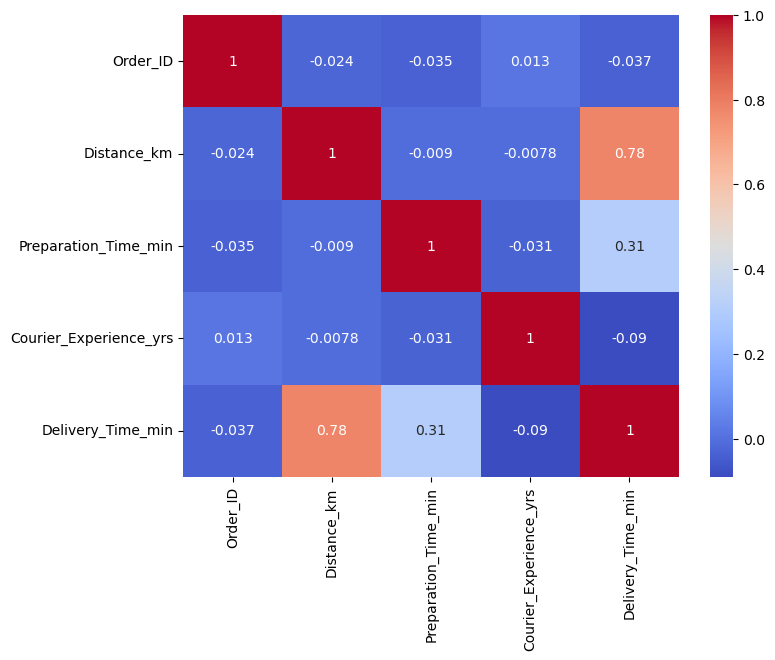

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [37]:
df = pd.get_dummies(df, drop_first=True)

In [38]:
df = df.dropna()

In [40]:
y = df["Delivery_Time_min"]
X = df.drop("Delivery_Time_min", axis=1)

X = pd.get_dummies(X, drop_first=True)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 96.66781074702281
R2 Score: 0.8081451415857759


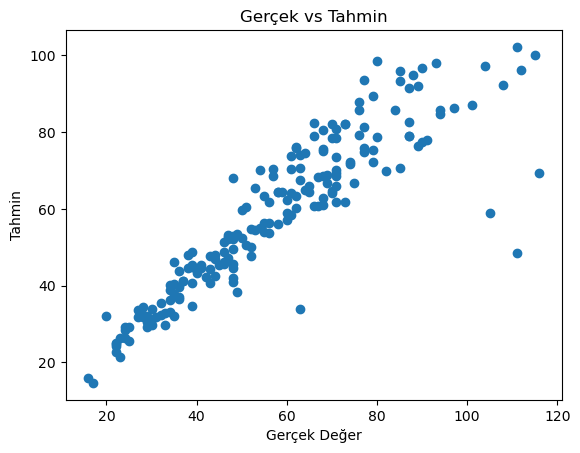

In [46]:
plt.scatter(y_test, y_pred)
plt.xlabel("Gerçek Değer")
plt.ylabel("Tahmin")
plt.title("Gerçek vs Tahmin")
plt.show()

In [ ]:
. SONUÇLARIN AÇIKLANMASI
MAE: Ortalama tahmin hatasını gösterir.
MSE: Büyük hataları daha fazla cezalandırır.
R² Score: Model başarısını gösterir. 1’e yakın olması iyi performansı ifade eder.

In [ ]:
7.# MODEL NE İŞE YARAR?

Bu model sayesinde:

Sipariş verilmeden önce tahmini teslim süresi hesaplanabilir

Firmalar kurye planlamasını optimize edebilir

Müşteri memnuniyeti artırılabilir